# Gráficas
> Para ejecutar un blóque de código hay descomentarlo y ejecutarlo. Mantener todos los blóques de código comentados permite hacer `Run All` en el notebook para ejecutar el primer bloque de código (carga de dataset, librerías generales, etc) y el bloque objetivo de forma rápida. 

#### 1. Cargar dataset y mostrar ejemplo

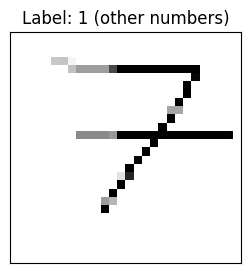

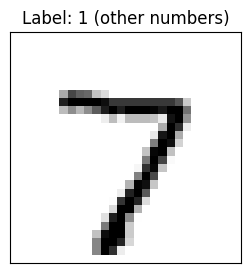

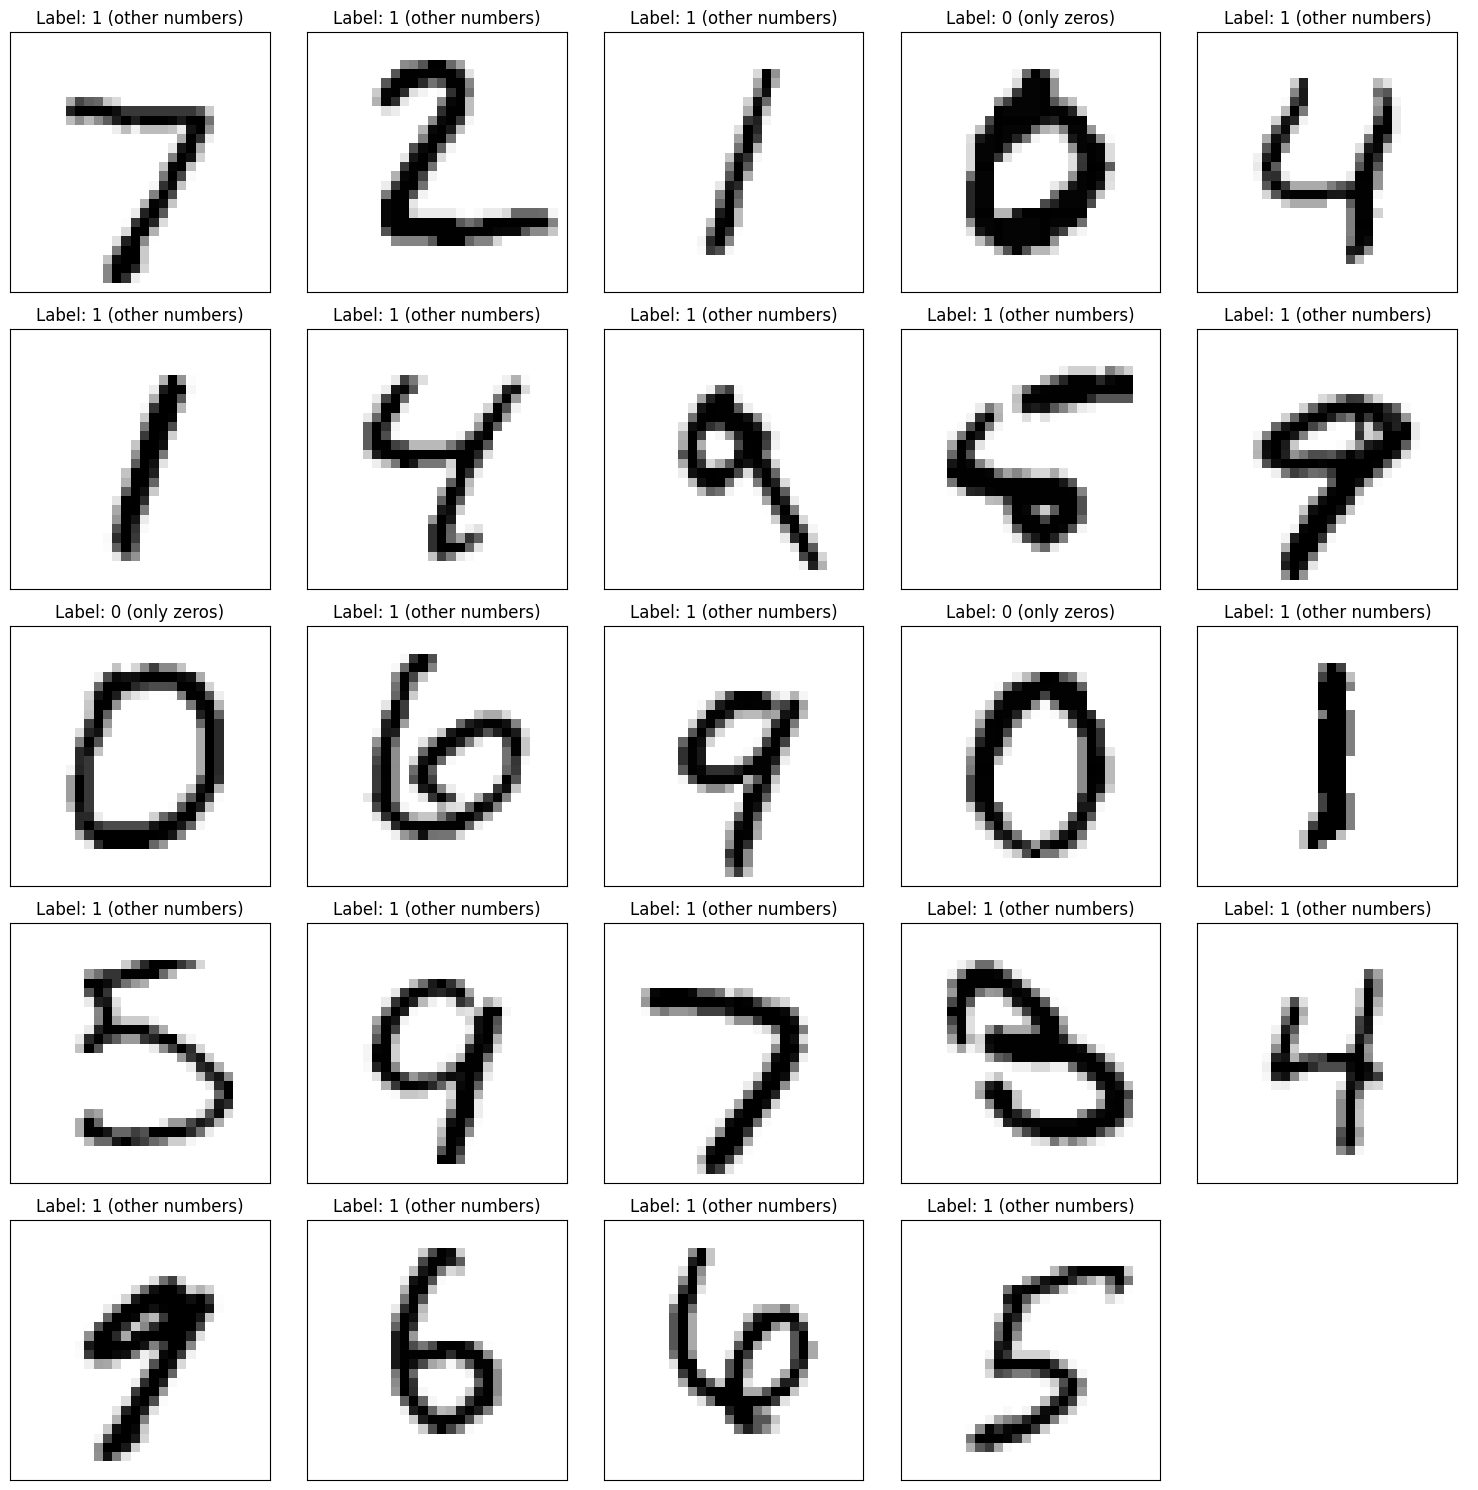

In [1]:
from utils.datasets import load_dataset, show_digit, show_digits, process_new_image
from sklearn.model_selection import train_test_split as tts
from tqdm import tqdm


sample_image, sample_label = process_new_image("sample_7_900.png", 1)
data, labels = load_dataset()

show_digit(sample_image, sample_label)
show_digit(data[0], labels[0])
show_digits(data[:24], labels[:24])

### 2. Plots con un solo modelo

#### Linear y Quadratic

In [2]:
# from utils.models import Linear

# X_train, X_test, y_train, y_test = tts(data, labels, test_size=0.3)

# linear = Linear()
# linear.fit(X_train, y_train)
# linear.evaluate_f1(X_test, y_test)

#### KNN variando K, mostrar varias líneas, 1 por cada repetición. `DONE`

In [3]:
# from utils.models import KNN
# from utils.visualization import plot_knn_f1

# knn_f1_scores_list = []
# n_reps = 2
# neighbours = 2

# pbar = tqdm(total=n_reps * neighbours)
# for n_rep in range(n_reps):
#     X_train, X_test, y_train, y_test = tts(
#         data, labels, test_size=0.3, random_state=n_rep
#     )
#     knn_f1_scores = []
#     for neighbour in range(neighbours):
#         knn = KNN(n_neighbors=neighbour + 1)
#         knn.fit(X_train, y_train)
#         score = knn.evaluate_f1(X_test, y_test)
#         knn_f1_scores.append(score)
#         pbar.update(1)

#     knn_f1_scores_list.append(knn_f1_scores)

# pbar.close()
# plot_knn_f1(f1_scores=knn_f1_scores_list)

#### MLP variando neuronas de primera capa, varias líneas, 1 por cada repetición. `DONE`

In [4]:
# from utils.models import MLP
# import numpy as np
# from matplotlib import pyplot as plt


# X_train, X_test, y_train, y_test = tts(data, labels, test_size=0.95)

# f1_scores_list = []
# pbar = tqdm(total=5 * 5)

# layer_grid = [1, 6, 11, 16, 21]

# # 5x5 grid de f1 scores de MLPs
# for i in layer_grid:
#     f1_scores = []
#     for j in layer_grid:
#         mlp = MLP(hidden_layer_sizes=(i, j), max_iter=1500)
#         mlp.fit(X_train, y_train)
#         score = mlp.evaluate_f1(X_test, y_test)
#         f1_scores.append(round(score, 2))
#         pbar.update(1)

#     f1_scores_list.append(f1_scores)

# pbar.close()
# # Mostramos la gráfica
# datos = np.array(f1_scores_list)
# fig, ax = plt.subplots()
# im = ax.imshow(datos, cmap="hot", interpolation="nearest")

# # Mostramos los números en cada celda
# for i in range(datos.shape[0]):
#     for j in range(datos.shape[1]):
#         text = ax.text(j, i, datos[i, j], ha="center", va="center", color="r")

# # Configuramos los ejes
# ax.set_xticks(np.arange(datos.shape[1]))
# ax.set_yticks(np.arange(datos.shape[0]))
# ax.set_xticklabels(layer_grid)
# ax.set_yticklabels(layer_grid)
# ax.set_xlabel("Neurons L2")
# ax.set_ylabel("Neurons L1")

# plt.show()

### 3. Plots con varios modelos

#### Gráfica Curva ROC, varias líneas, 1 por cada modelo.

In [5]:
from utils.models import *
mlp = MLP()
X_train, X_test, y_train, y_test = tts(data, labels, test_size=0.95, random_state=42)

mlp.fit(X_train, y_train)

# cm = mlp.get_confusion_matrix(X_test, y_test)

AttributeError: 'MLP' object has no attribute 'get_confusion_matrix'

#### Gráfica mostrando la velocidad de aprendizaje de cada modelo `DONE`

Training kmeans model: 100%|██████████| 35/35 [00:13<00:00,  2.58it/s]


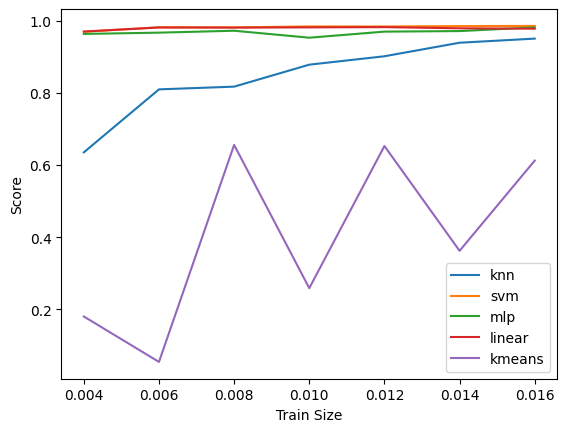

In [6]:
from utils.models import *
import matplotlib.pyplot as plt  

random_state = 42
train_sizes = [0.004, 0.006, 0.008, 0.01, 0.012, 0.014, 0.016]
# train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

models = {
    "knn": KNN(),
    "svm": SVM(),
    "mlp": MLP(),
    "linear": Linear(), 
    "kmeans": KMeans(),
}

pbar = tqdm(total=len(models) * len(train_sizes))
for name, model in models.items():
    scores = []
    pbar.set_description(f"Training {name} model")
    for train_size in train_sizes:
        X_train, X_test, y_train, y_test = tts(
            data,
            labels,
            test_size=1 - train_size,
            random_state=random_state,
        )
        model.fit(X_train, y_train)
        score = model.evaluate_f1(X_test, y_test)
        scores.append(score)
        pbar.update(1)
    plt.plot(train_sizes, scores, label=name)

pbar.close()
plt.xlabel("Train Size")
plt.ylabel("Score")
plt.legend()
plt.show()